# K-Means Clustering for Tech Job Family Identification

## Overview

This notebook covers the **clustering component** of our Tech Job Market Analysis and Recommendation System. We use K-Means clustering on the merged job postings dataset to group similar roles together. Sorting natural categories like *Data Engineer*, *ML Engineer*, and *AI Engineer* based on the skills and titles in the data.

These cluster labels are used in two ways across the project:
1. **Market insight**: Showing which types of tech jobs appear most frequently in the dataset.
2. **Recommendation support**: Giving each job posting a family label that the recommendation engine can use to return better matches.

### Notebook Pipeline

| Step | Description |
|------|-------------|
| 1 | Load and preprocess the merged job postings dataset |
| 2 | Vectorize job text (title + standardized skills) using TF-IDF |
| 3 | Evaluate multiple values of *k* using inertia and silhouette score |
| 4 | Fit the final K-Means model and assign human-readable job family labels |
| 5 | Assess cluster cohesion and inspect representative examples per family |

---

## Step 1: Load and Prepare Data

We start by loading the merged dataset created during the preprocessing stage of the project. Rows that are missing both a job title and skills are dropped, since there isn't enough information to cluster them meaningfully. We then build a `text_for_clustering` field by combining the job title and skill tags into a single string. This way, the model has both the role name and its required skills to work with when forming groups.

In [ ]:
import pandas as pd

# Load the merged dataset used for clustering
csv_path = "Datasets/merged ai and job market.csv"
df = pd.read_csv(csv_path)

# Keep only rows with enough text signal for clustering
df = df.copy()
df["title"] = df["title"].fillna("").astype(str)
df["skills_standardized"] = df["skills_standardized"].fillna("").astype(str)

# Build the text description used for vectorization
df["text_for_clustering"] = (
    df["title"].str.strip() + " | " + df["skills_standardized"].str.strip()
).str.strip(" |")

# Remove empty text rows
df = df[df["text_for_clustering"].str.len() > 0].reset_index(drop=True)

print(f"Rows available for clustering: {len(df):,}")
print(df[["title", "skills_standardized", "text_for_clustering"]].head(3))

Rows available for clustering: 11,508
                       title                          skills_standardized  \
0                ai engineer                                deep_learning   
1  machine learning engineer  cloud_computing;machine_learning;python;sql   
2  machine learning engineer      cloud_computing;machine_learning;python   

                                 text_for_clustering  
0                        ai engineer | deep_learning  
1  machine learning engineer | cloud_computing;ma...  
2  machine learning engineer | cloud_computing;ma...  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Prepare skills_text to match Recommendations_w_TF-IDF preprocessing
df["skills_standardized"] = df["skills_standardized"].fillna("").astype(str)
df["skills_text"] = (
    df["skills_standardized"]
    .str.replace(";", " ")
    .str.replace(",", " ")
    .str.lower()
    .str.strip()
)
# Optionally include title to add contextual signal (set to False to use skills only)
include_title = True
if include_title:
    df["skills_text"] = (df["title"].fillna("").str.lower() + " " + df["skills_text"]).str.strip()

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["skills_text"])

print(f"TF-IDF matrix shape: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out()):,}")
print(f"Sparsity: {(1 - X.nnz / (X.shape[0] * X.shape[1])):.4f}")

TF-IDF matrix shape: (11508, 406)
Vocabulary size: 406
Sparsity: 0.9797


## Step 2: TF-IDF Vectorization

Here we convert each job posting into a numerical representation using **TF-IDF**, which is the same approach used in the recommendation module. This keeps things consistent across the project.

Each posting's skills are cleaned up (separators removed, text lowercased) and combined with the job title into a single `skills_text` field. TF-IDF then scores each word based on how often it appears in a posting versus how common it is across all postings. Terms like *machine_learning* or *deep_learning* that are specific to certain roles carry more weight than generic words such as *developer*, *team*, or *experience*.



## Step 3: Choosing the Right Number of Clusters (*k*)

Before we can run K-Means, we need to decide how many clusters to use. We test values of *k* from 3 to 12 and compare results using two metrics:

- **Inertia**: Measures how tightly packed each cluster is. Lower is better, but it keeps dropping as *k* increases, so it can't be used alone.
- **Silhouette Score**: Measures how well each data point fits its assigned cluster compared to neighboring ones. Higher is better, and it peaks at a meaningful *k*.

Looking at both together helps us find a good balance, where clusters are tight but not arbitrarily over-split. Since computing silhouette scores on the full dataset is slow, we run it on a random sample of up to 4,000 rows.

,k,inertia,silhouette
0,3,7568.236819,0.149651
1,4,6883.547175,0.188664
2,5,6387.427777,0.215425
3,6,5909.283435,0.225708
4,7,5571.531114,0.239177
5,8,5384.000722,0.237676
6,9,5238.488403,0.235396
7,10,5127.125908,0.224494
8,11,4941.584540,0.232563
9,12,4852.176989,0.230485


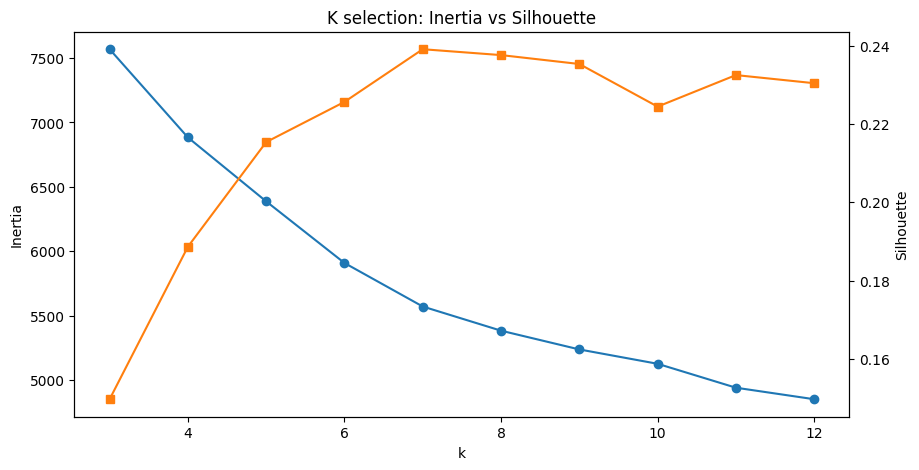

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = list(range(3, 13))
results = []

sample_size = min(4000, X.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)
X_sample = X[sample_idx]

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)

    sil = silhouette_score(X_sample, labels[sample_idx])
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": sil,
    })

k_eval = pd.DataFrame(results)
display(k_eval)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(k_eval["k"], k_eval["inertia"], marker="o", label="Inertia")
ax2.plot(k_eval["k"], k_eval["silhouette"], marker="s", color="tab:orange", label="Silhouette")

ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax2.set_ylabel("Silhouette")
ax1.set_title("K selection: Inertia vs Silhouette")

plt.show()

## Step 4: Fitting the Final Model and Labeling Job Families

Based on Step 3, **k = 7** gives the best silhouette score, so we use that for our final model. We re-fit K-Means with 30 random starts (`n_init=30`) to make sure we're getting a good result and not just getting lucky with the initial centroid placement.

Once the model is fit, we look at the top terms associated with each cluster to figure out what kind of jobs ended up in it. From there, we manually assign a readable label to each cluster (e.g., *ML Engineer*, *Data Analyst*, *Business Analyst*) and map those labels back to every row in the dataset.


In [ ]:
best_k = 7
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=30)
df["cluster_id"] = final_kmeans.fit_predict(X)

terms = vectorizer.get_feature_names_out()
centers = final_kmeans.cluster_centers_


def top_terms_for_cluster(cluster_idx: int, n_terms: int = 10):
    top_idx = centers[cluster_idx].argsort()[::-1][:n_terms]
    return [terms[i] for i in top_idx]

cluster_top_terms = {
    c: top_terms_for_cluster(c, n_terms=10)
    for c in range(best_k)
}

cluster_summary = pd.DataFrame({
    "cluster_id": list(cluster_top_terms.keys()),
    "top_terms": [", ".join(v) for v in cluster_top_terms.values()],
    "size": [int((df["cluster_id"] == c).sum()) for c in cluster_top_terms.keys()],
}).sort_values("size", ascending=False)

display(cluster_summary)

# Starter labels selected from observed top terms in this run.
# Edit this map if your future run reorders cluster IDs.
cluster_label_map = {
    0: "Data Engineer",
    1: "Data Scientist",
    2: "AI Engineer",
    3: "Other / Mixed",
    4: "ML Engineer",
    5: "Data Analyst",
    6: "Business Analyst",
}

df["job_family"] = df["cluster_id"].map(cluster_label_map)

print("Cluster -> Label mapping (editable):")
for c in sorted(cluster_label_map):
    print(f"Cluster {c}: {cluster_label_map[c]} | top terms: {cluster_top_terms[c][:6]}")

print("\nCluster size by labeled family:")
display(df["job_family"].value_counts().rename_axis("job_family").reset_index(name="count"))

,cluster_id,top_terms,size
4,4,"machine learning, machine, learning engineer, ...",1746
6,6,"business analyst, business, analyst, analyst c...",1716
2,2,"ai engineer, ai, engineer, engineer cloud_comp...",1705
1,1,"data scientist, scientist, data, scientist clo...",1704
5,5,"data analyst, analyst, data, analyst cloud_com...",1654
0,0,"data engineer, data, engineer, engineer cloud_...",1637
3,3,"unknown, cloud_computing, time, analyst unknow...",1346


Cluster -> Label mapping (editable):
Cluster 0: Data Engineer | top terms: ['data engineer', 'data', 'engineer', 'engineer cloud_computing', 'cloud_computing', 'deep_learning']
Cluster 1: Data Scientist | top terms: ['data scientist', 'scientist', 'data', 'scientist cloud_computing', 'scientist deep_learning', 'machine_learning']
Cluster 2: AI Engineer | top terms: ['ai engineer', 'ai', 'engineer', 'engineer cloud_computing', 'deep_learning', 'cloud_computing']
Cluster 3: Other / Mixed | top terms: ['unknown', 'cloud_computing', 'time', 'analyst unknown', 'python', 'engineer unknown']
Cluster 4: ML Engineer | top terms: ['machine learning', 'machine', 'learning engineer', 'learning', 'engineer', 'engineer cloud_computing']
Cluster 5: Data Analyst | top terms: ['data analyst', 'analyst', 'data', 'analyst cloud_computing', 'analyst deep_learning', 'deep_learning']
Cluster 6: Business Analyst | top terms: ['business analyst', 'business', 'analyst', 'analyst cloud_computing', 'machine_lear

,job_family,count
0,ML Engineer,1746
1,Business Analyst,1716
2,AI Engineer,1705
3,Data Scientist,1704
4,Data Analyst,1654
5,Data Engineer,1637
6,Other / Mixed,1346


## Step 5: Checking Cluster Quality and Reviewing Examples

With the model fitted and labels assigned, we do a final check to make sure the clusters actually make sense.

First, we compute **per-cluster silhouette scores** on a random sample to see which job families are most clearly separated. A high score (like *ML Engineer*) means those jobs have a distinct enough skill set that the model had no trouble grouping them. A low or negative score (like *Other / Mixed*) means those postings were ambiguous, meaning they didn't fit cleanly into any one category.

Next, we pull a few example postings from each cluster so we can visually confirm the labels make sense given the job titles and skills listed.

Finally, the clustered dataset is saved to `Datasets/jobs_with_clusters.csv` to be used by the recommendation engine.

In [ ]:
from sklearn.metrics import silhouette_samples

# Mean silhouette by cluster (sampled for speed)
sample_size = min(4000, X.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)

sample_labels = df.loc[sample_idx, "cluster_id"].values
sample_sil = silhouette_samples(X[sample_idx], sample_labels)

cohesion = (
    pd.DataFrame({
        "cluster_id": sample_labels,
        "silhouette": sample_sil,
    })
    .groupby("cluster_id", as_index=False)["silhouette"]
    .mean()
    .sort_values("silhouette", ascending=False)
)

cohesion["job_family"] = cohesion["cluster_id"].map(cluster_label_map)
display(cohesion)

# Show representative examples from each family
examples = (
    df[["title", "skills_standardized", "job_family", "cluster_id"]]
    .groupby(["job_family", "cluster_id"], group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

display(examples)

# Save output for downstream recommendation or analysis
output_path = "Datasets/jobs_with_clusters.csv"
df.to_csv(output_path, index=False)
print(f"Saved clustered dataset to: {output_path}")

,cluster_id,silhouette,job_family
4,4,0.375770,ML Engineer
1,1,0.268204,Data Scientist
2,2,0.264545,AI Engineer
6,6,0.253719,Business Analyst
0,0,0.236708,Data Engineer
5,5,0.220237,Data Analyst
3,3,-0.000609,Other / Mixed


,title,skills_standardized,job_family,cluster_id
0,ai engineer,deep_learning,AI Engineer,2
1,machine learning engineer,cloud_computing;machine_learning;python;sql,ML Engineer,4
2,machine learning engineer,cloud_computing;machine_learning;python,ML Engineer,4
3,business analyst,cloud_computing;deep_learning;sql,Business Analyst,6
4,data scientist,machine_learning;python;sql,Data Scientist,1
5,machine learning engineer,deep_learning;machine_learning;python,ML Engineer,4
6,data scientist,unknown,Data Scientist,1
7,data analyst,cloud_computing;machine_learning;python,Data Analyst,5
8,machine learning engineer,cloud_computing,ML Engineer,4
9,data engineer,cloud_computing;python,Data Engineer,0


Saved clustered dataset to: Datasets/jobs_with_clusters.csv
